# Post-analysis

Stage 3 of 3 of the analysis plan ([`final-analysis-plan.md`](../../docs/analysis/final-analysis-plan.md) §5).

**Status: unresolved.** Which robustness checks, instrument extensions, channel analyses and
interpretation steps run here, in what order and with which decision rules, is left open until
the go/no-go decision that follows the core analysis (`02_core_analysis.ipynb`). The candidate
list is in plan §5:

- **Measurement:** 11A1 vs 21A2; entanglement share; coverage-balanced outcome with bounds;
  panel end 2020 vs 2022; the |φ| ≤ 60° cut.
- **Instruments:** baseline-share price shock; masked donut; event study at mine openings;
  shift-share diagnostics; GLASS-AVHRR placebo; favoritism at ADM2.
- **Inference and specification:** Conley SEs; specification curve.
- **Channels and heterogeneity:** land-cover fractions and PM2.5 as outcomes; baseline
  land-cover strata; GLASS vs LST; heterogeneity; neighbouring-cell outcome.
- **Interpretation:** complier profile; TOST bounds; reframing rules.

What is below was already run before the split.

In [ ]:
import sys
from pathlib import Path
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))
from src.analysis.spec import (   # the fixed specification (plan §2)
    PANEL, NTL_HI, COV_MIN, Y, Y_DAY, XLOG, Z, M, FE, FE_CTY, BASE,
    build_panel, fit, row, reg_table, first_stage_F,
    CL, DR, duckreg, coefplot,
)

build_panel()                     # cached: <data>/_analysis_panel_10km.parquet
P = f"read_parquet('{PANEL}')"  # for DuckDB queries on the panel
sql = lambda q: duckdb.sql(q).df()

# Reference fits the carried-over blocks compare against.
m_twfe = fit(f"{Y} ~ {XLOG} | {FE}")
m_iv   = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})")

## Carried-over robustness blocks (R1–R9)

Carried over verbatim, with their outputs, from `regression.ipynb` (run 2026-09-28, SLURM job
24182913). The blocks were **not re-run** after the split. Their inputs are identical: same rows,
same specification, now read from `src/analysis/spec.py`. Two parts moved to other notebooks:
the selection regression in R4 is now pre-analysis P3, and day-LST TWFE in R5 is now core C1.
Both are left in the code below so the carried-over outputs still match it.

Each block holds the 2SLS spec fixed and varies a single axis. All SEs are
cluster-robust (`GID_1`).

### R1. NTL functional form

`ntl_harm` is ~68 % exact zeros. `log1p` is the baseline; `asinh` needs no offset;
`1{ntl_harm >= 20}` and `1{>= 30}` are lit indicators; `log(ntl_harm)` on the
`ntl_harm >= 20` sub-sample uses only already-lit pixel-years. These are functional
forms, not the extensive / intensive *margins* the review asks for: those need baseline
land-cover strata (plan §3.1, Phase 6b).

In [8]:
r1_asinh = fit(f"{Y} ~ 1 | {FE} | (asinh_ntl ~ {Z})")
r1_lit   = fit(f"{Y} ~ 1 | {FE} | (lit_hi ~ {Z})")
r1_lit30 = fit(f"{Y} ~ 1 | {FE} | (lit_30 ~ {Z})")
r1_int   = fit(f"{Y} ~ 1 | {FE} | (log_ntl_int ~ {Z})", subset=f"ntl_harm >= {NTL_HI}")
pd.concat([
    reg_table([m_iv],     ["baseline log1p"],  XLOG),
    reg_table([r1_asinh], ["asinh"],           "asinh_ntl"),
    reg_table([r1_lit],   ["1{>=20}"],         "lit_hi"),
    reg_table([r1_lit30], ["1{>=30}"],         "lit_30"),
    reg_table([r1_int],   ["log | >=20"],      "log_ntl_int"),
])

,estimate,std_error,p
spec,,,
baseline log1p,-0.0259,0.1503,0.8630
asinh,-0.0212,0.1229,0.8630
1{>=20},-0.1761,1.0246,0.8635
1{>=30},-0.2695,1.5582,0.8627
log | >=20,5.8449,13.6588,0.6687


**Result** (2SLS endogenous-term coefficient; SE clustered by `GID_1`).

| baseline log1p | asinh | `1{>=20}` | `1{>=30}` | `log | >=20` |
|---:|---:|---:|---:|---:|
| -0.026 (0.150) | -0.021 (0.123) | -0.18 (1.02) | -0.27 (1.56) | +5.8 (13.7) |

**Interpretation.** Every transform rescales the same null reduced form (p ~ 0.86 in all
four full-sample rows). The already-lit sub-sample has no usable first stage. Functional
form does not matter here.

### R2. DMSP -> VIIRS harmonization break

`ntl_harm` splices DMSP-OLS (through ~2013) to a VIIRS-based series. Baseline vs
drop the 2013-2014 transition, DMSP era only (`year <= 2012`), and a sensor-era
slope interaction (TWFE OLS).

In [9]:
r2_drop = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", subset="year NOT IN (2013, 2014)")
r2_dmsp = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", subset="year <= 2012")
reg_table([m_iv, r2_drop, r2_dmsp], ["baseline", "drop 2013-14", "DMSP only (<=2012)"], XLOG)

,estimate,std_error,p
spec,,,
baseline,-0.0259,0.1503,0.8630
drop 2013-14,-0.0336,0.1568,0.8304
DMSP only (<=2012),-0.0326,0.2670,0.9028


In [10]:
# Era-interacted TWFE OLS (needs the interaction columns materialised).
con = duckdb.connect()
era_df = con.execute(f"""
    SELECT {Y}, pixel_id, GID_0, GID_1, biome_id, year, {XLOG},
           {XLOG} * (era = 'overlap')::INT AS log_ntl_x_overlap,
           {XLOG} * (era = 'viirs')::INT   AS log_ntl_x_viirs
    FROM read_parquet('{PANEL}') WHERE {BASE}
""").fetchdf()
con.close()
r2_era = duckreg(
    f"{Y} ~ {XLOG} + log_ntl_x_overlap + log_ntl_x_viirs | {FE}",
    data=era_df, se_method=CL, **DR,
)
del era_df
r2_era.tidy()

,variable,estimate,std_error,t_stat,p_value,ci_lower,ci_upper
0,log_ntl,-0.043853,0.007104,-6.172857,6.706697e-10,-0.057777,-0.029929
1,log_ntl_x_overlap,0.025512,0.010427,2.446663,1.441858e-02,0.005075,0.045950
2,log_ntl_x_viirs,0.016099,0.006308,2.552214,1.070408e-02,0.003736,0.028463


**Result.** 2SLS: baseline -0.026 (0.150); drop 2013-14 -0.034 (0.157); DMSP era only
-0.033 (0.267). Era-interacted TWFE OLS: DMSP-era slope **-0.044** (0.007), overlap-year
shift +0.026 (0.010), VIIRS-era shift **+0.016** (0.006).

**Interpretation.** The IV does not depend on the sensor splice. The OLS association is
~40 % weaker in the VIIRS era (-0.028 vs -0.044), a significant difference: part of the
DMSP-era gradient may reflect DMSP's blur and saturation rather than lights. Worth keeping
the sensor-era interaction in the Phase 2 OLS benchmark.

### R3. Gas flares

The baseline drops flare pixel-years (`flare_band > 0`, VIIRS era only, ~1 % of those
rows). Compared with the unmasked panel.

In [11]:
r3_all = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", base=False)
reg_table([m_iv, r3_all], ["baseline (flares dropped)", "flares kept"], XLOG)

,estimate,std_error,p
spec,,,
baseline (flares dropped),-0.0259,0.1503,0.8630
flares kept,-0.0330,0.1530,0.8291


**Result.** Flares dropped (baseline) -0.026 (0.150); flares kept -0.033 (0.153).

**Interpretation.** The flare mask (134 k pixel-years) does not move the estimate. It stays
in the baseline for cleanliness.

### R4. Night-LST coverage

The annual night LST is a composite of clear-sky 8-day periods. If the instrument
changes how many periods are observed (haze, aerosols), the composite is selected.
`cov_night` = this year's valid pixel-months / the pixel's best year (the raw counts
are sums over ~100 native cells, so an absolute cut-off would mostly select coastal
cells). First the selection check (reduced form of coverage on the instrument), then
the 2SLS on high-coverage pixel-years. This is the quick version of plan Phase 1b.

In [12]:
r4_sel = fit(f"cov_night ~ {Z} | {FE}")
r4 = [fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", subset=f"cov_night >= {c}") for c in (COV_MIN, 0.9)]
cov_q = duckdb.sql(f"SELECT avg(cov_night), avg((cov_night >= {COV_MIN})::INT), "
                   f"avg((cov_night >= 0.9)::INT) FROM read_parquet('{PANEL}')").fetchone()
print(f"mean cov_night {cov_q[0]:.3f} | share >= {COV_MIN}: {cov_q[1]:.3f} | share >= 0.9: {cov_q[2]:.3f}")
pd.concat([
    reg_table([r4_sel], [f"selection: d cov_night / d {Z}"], Z),
    reg_table([m_iv] + r4, ["2SLS baseline", f"2SLS cov_night >= {COV_MIN}", "2SLS cov_night >= 0.9"], XLOG),
])

mean cov_night 0.888 | share >= 0.75: 0.837 | share >= 0.9: 0.687


,estimate,std_error,p
spec,,,
selection: d cov_night / d mine_count_20km,0.0012,0.0006,0.0316
2SLS baseline,-0.0259,0.1503,0.8630
2SLS cov_night >= 0.75,-0.0872,0.1054,0.4081
2SLS cov_night >= 0.9,-0.0361,0.1058,0.7333


**Result.** Mean within-pixel coverage is 0.89; 84 % of pixel-years reach 0.75 and 69 %
reach 0.9. Selection check: `cov_night` on the instrument = **+0.0012** (0.0006), p ~ 0.03.
2SLS on high-coverage pixel-years: -0.087 (0.105) at >= 0.75, -0.036 (0.106) at >= 0.9.

**Interpretation.** Mine exposure slightly *raises* night-LST coverage -- detectable, but
0.1 percentage points of coverage per mine. Restricting to well-covered pixel-years leaves
the 2SLS inside its baseline CI. Under the plan's Phase 1b rule this counts as detected
selection, so the full 1b analysis (coverage-balanced outcome with Lee bounds) is needed
before Phase 4; this quick version suggests it will not change the conclusion.

### R5. Alternative outcomes and lights measure

**Day LST** and **GLASS near-surface air temperature** (`glass_ta_mean`, 2002-2020 here)
as outcomes, and raw **VIIRS median** (`viirs_annual_median`, 2013-2021, as
`log(viirs+1)`) as the lights measure. Day LST reacts to albedo changes; only a
*divergence* between GLASS and LST is informative, since GLASS is partly built from
land cover and remote sensing (plan Phase 6c).

In [13]:
r5_day_ols   = fit(f"lst_day_mean ~ {XLOG} | {FE}", subset="lst_day_mean IS NOT NULL")
r5_glass_ols = fit(f"glass_ta_mean ~ {XLOG} | {FE}", subset="glass_ta_mean IS NOT NULL")
r5_day   = fit(f"lst_day_mean ~ 1 | {FE} | ({XLOG} ~ {Z})",  subset="lst_day_mean IS NOT NULL")
r5_glass = fit(f"glass_ta_mean ~ 1 | {FE} | ({XLOG} ~ {Z})", subset="glass_ta_mean IS NOT NULL")
r5_viirs = fit(f"{Y} ~ 1 | {FE} | (log_viirs ~ {Z})",
               subset="year BETWEEN 2013 AND 2021 AND viirs IS NOT NULL")
print("VIIRS first-stage F:", round(first_stage_F("log_viirs", Z,
      subset="year BETWEEN 2013 AND 2021 AND viirs IS NOT NULL"), 1))
pd.concat([
    reg_table([m_twfe],       ["night LST -- TWFE OLS"],         XLOG),
    reg_table([r5_day_ols],   ["day LST -- TWFE OLS"],           XLOG),
    reg_table([r5_glass_ols], ["GLASS air temp -- TWFE OLS"],    XLOG),
    reg_table([m_iv],         ["night LST -- 2SLS"],             XLOG),
    reg_table([r5_day],       ["day LST -- 2SLS"],               XLOG),
    reg_table([r5_glass],     ["GLASS air temp -- 2SLS"],        XLOG),
    reg_table([r5_viirs],     ["VIIRS median 2013-21 -- 2SLS"],  "log_viirs"),
])

VIIRS first-stage F: 5.2


,estimate,std_error,p
spec,,,
night LST -- TWFE OLS,-0.0300,0.0056,0.0000
day LST -- TWFE OLS,-0.0147,0.0123,0.2319
GLASS air temp -- TWFE OLS,-0.0181,0.0040,0.0000
night LST -- 2SLS,-0.0259,0.1503,0.8630
day LST -- 2SLS,0.0993,0.2325,0.6693
GLASS air temp -- 2SLS,0.0760,0.0852,0.3721
VIIRS median 2013-21 -- 2SLS,-3.7445,4.5216,0.4076


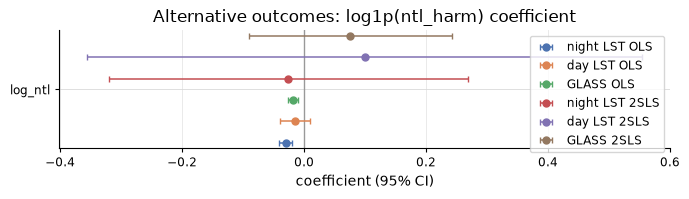

In [14]:
# VIIRS omitted from the plot (different term, large SE; see table).
coefplot([m_twfe, r5_day_ols, r5_glass_ols, m_iv, r5_day, r5_glass],
         ["night LST OLS", "day LST OLS", "GLASS OLS", "night LST 2SLS", "day LST 2SLS", "GLASS 2SLS"],
         XLOG, "Alternative outcomes: log1p(ntl_harm) coefficient")

**Result.**

| | night LST | day LST | GLASS air temp |
|---|---:|---:|---:|
| TWFE OLS | **-0.030*** (0.006) | -0.015 (0.012) | **-0.018*** (0.004) |
| 2SLS | -0.026 (0.150) | +0.099 (0.233) | +0.076 (0.085) |

VIIRS median (2013-21) 2SLS: -3.7 (4.5), first-stage F ~ 5.

**Interpretation.**

- **OLS**: night LST and GLASS air temperature both show a small, precise negative
  association with lights; day LST does not. Night LST and GLASS agree, so the
  association is not a skin-temperature artefact.
- **2SLS**: all three outcomes are null. Day LST and GLASS turn positive, but both CIs
  cover the night-LST estimate. The old day-LST headline (-0.18) does not survive the
  country x biome x year FE: its sign was not robust.
- **VIIRS** on 2013-21 has a weak first stage (F ~ 5); uninformative.

### R6. Instrument choice

Mine-count radius (10 / 20 / 50 km), the price-shock instrument, and the
over-identified spec (count + price-shock). The price-shock instrument is not yet the
baseline-share version the plan makes primary (§3.3): its exposure still moves with
mine openings and closures.

In [15]:
r6_10 = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ mine_count_10km)")
r6_50 = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ mine_count_50km)")
r6_ps = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ mine_priceshock_20km)")
r6_oi = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z} + mine_priceshock_20km)")
for lbl, ins in [("20 km", Z), ("10 km", "mine_count_10km"), ("50 km", "mine_count_50km"),
                 ("price-shock", "mine_priceshock_20km")]:
    print(f"{lbl:12s} first-stage F: {first_stage_F(XLOG, ins):.1f}")
reg_table([m_iv, r6_10, r6_50, r6_ps, r6_oi],
          ["20 km", "10 km", "50 km", "price-shock", "over-ID"], XLOG)

20 km        first-stage F: 71.0


10 km        first-stage F: 139.4


50 km        first-stage F: 21.9


price-shock  first-stage F: 32.3


,estimate,std_error,p
spec,,,
20 km,-0.0259,0.1503,0.8630
10 km,0.0332,0.0802,0.6787
50 km,-0.2185,0.3254,0.5019
price-shock,0.2611,0.2803,0.3516
over-ID,-0.0144,0.1486,0.9229


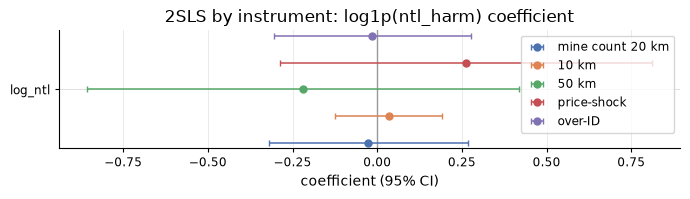

In [16]:
coefplot([m_iv, r6_10, r6_50, r6_ps, r6_oi],
         ["mine count 20 km", "10 km", "50 km", "price-shock", "over-ID"],
         XLOG, "2SLS by instrument: log1p(ntl_harm) coefficient")

**Result** (2SLS coefficient; first-stage F with admin-1 clustering above the table).

| 20 km (base) | 10 km | 50 km | price-shock | over-ID (count + PS) |
|---:|---:|---:|---:|---:|
| -0.026 (0.150) | +0.033 (0.080) | -0.22 (0.33) | +0.26 (0.28) | -0.014 (0.149) |
| F ~ 71 | F ~ 139 | F ~ 22 | F ~ 32 | |

**Interpretation.** Every instrument has a strong first stage and every 2SLS is null. The
old day-LST finding that all instruments agree on a negative sign no longer holds: signs
now scatter around zero. The 10 km instrument gives the tightest CI, about [-0.12, +0.19].

### R7. Inference

Same 2SLS point estimate, different `se_method`: cluster by first-level admin
(`GID_1`, baseline), by country (`GID_0`), two-way (admin-1 and year), and
heteroskedasticity-robust (HC1). Conley spatial SEs and Anderson-Rubin CIs are not yet
available in `duckreg` (plan §6).

In [17]:
r7 = [
    m_iv,
    fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", se={"CRV1": "GID_0"}),
    fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", se={"CRV1": "GID_1 + year"}),
    fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ {Z})", se="HC1"),
]
reg_table(r7, ["cluster GID_1", "cluster GID_0", "two-way (GID_1, year)", "hetero (HC1)"], XLOG)

,estimate,std_error,p
spec,,,
cluster GID_1,-0.0259,0.1503,0.8630
cluster GID_0,-0.0259,0.1275,0.8388
"two-way (GID_1, year)",-0.0259,0.1503,0.8630
hetero (HC1),-0.0259,0.0237,0.2732


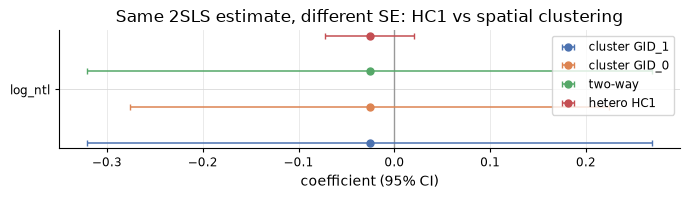

In [18]:
coefplot(r7, ["cluster GID_1", "cluster GID_0", "two-way", "hetero HC1"],
         XLOG, "Same 2SLS estimate, different SE: HC1 vs spatial clustering")

**Result** (same point estimate -0.026; only the SE changes).

| cluster GID_1 | cluster GID_0 | two-way (GID_1, year) | hetero (HC1) |
|---:|---:|---:|---:|
| 0.150 | 0.128 | 0.150 | **0.024** |

**Interpretation.** Admin-1 clustering is the most conservative of the clustered SEs and
is kept as the baseline. HC1 is ~6x too small. Conley SEs are still needed (plan §6).

### R8. Fixed effects

Baseline pixel + country x biome x year vs the previous pixel + country x year.
Country x biome x year compares cells to others in the same country, biome and year,
which absorbs biome-specific climate shocks.

In [19]:
r8_cty = fit(f"{Y} ~ 1 | {FE_CTY} | ({XLOG} ~ {Z})")
print(f"first-stage F -- cty x biome x year: {first_stage_F(XLOG, Z):.1f} | "
      f"cty x year: {first_stage_F(XLOG, Z, fe=FE_CTY):.1f}")
reg_table([m_iv, r8_cty], ["pixel + cty x biome x year", "pixel + cty x year"], XLOG)

first-stage F -- cty x biome x year: 71.0 | cty x year: 66.9


,estimate,std_error,p
spec,,,
pixel + cty x biome x year,-0.0259,0.1503,0.8630
pixel + cty x year,-0.0863,0.1736,0.6191


**Result.** 2SLS: pixel + cty x biome x year -0.026 (0.150), F ~ 71; pixel + cty x year
-0.086 (0.174), F ~ 67.

**Interpretation.** The FE choice moves the point estimate by less than half an SE and
leaves the first stage intact.

### R9. Alternative instrument -- political favoritism (`reg_fav`)

`reg_fav` (PLAD) flags a pixel whose region is the national leader's birth region in a
given year. Favored regions may get more public investment and electrification, so
`reg_fav -> ntl_harm`. It is time-varying (leaders change), unlike a fixed mine
location. The plan re-specifies it at ADM2 with region FE (Phase 3d); this is the
pixel-FE version.

In [20]:
r9_fs = fit(f"{XLOG} ~ reg_fav | {FE}")
r9_iv = fit(f"{Y} ~ 1 | {FE} | ({XLOG} ~ reg_fav)")
r9_rf = fit(f"{Y} ~ reg_fav | {FE}")
r = row(r9_fs, "reg_fav")
print(f"reg_fav first-stage F: {(r['est'] / r['se']) ** 2:.2f}   (b={r['est']:+.4f}, se={r['se']:.4f})")
pd.concat([
    reg_table([r9_fs], ["first stage  d log_ntl / d reg_fav"], "reg_fav"),
    reg_table([r9_rf], ["reduced form d lst / d reg_fav"],     "reg_fav"),
    reg_table([r9_iv], ["2SLS  d lst / d log_ntl"],            XLOG),
])

reg_fav first-stage F: 1.43   (b=+0.0106, se=0.0088)


,estimate,std_error,p
spec,,,
first stage d log_ntl / d reg_fav,0.0106,0.0088,0.2310
reduced form d lst / d reg_fav,0.0294,0.0216,0.1730
2SLS d lst / d log_ntl,2.7776,2.8543,0.3305


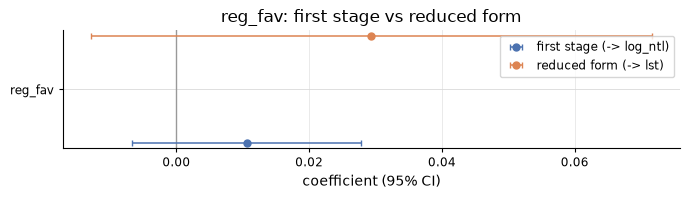

In [21]:
# First stage vs reduced form on the reg_fav coefficient; the 2SLS ratio is omitted.
coefplot([r9_fs, r9_rf], ["first stage (-> log_ntl)", "reduced form (-> lst)"],
         "reg_fav", "reg_fav: first stage vs reduced form")

**Result.** `reg_fav` first stage +0.011 (0.009), **F ~ 1.4**; reduced form on night LST
+0.029 (0.022), p ~ 0.17; 2SLS +2.8 (2.9), meaningless.

**Interpretation.** The first stage is still dead under pixel FE. The positive
reduced form that was significant for day LST (+0.09, p ~ 0.04 under country x year FE) is
a third of that size and not significant for night LST. Favoritism stays out of the
pixel-FE design; the ADM2 re-specification (plan Phase 3d) is its only remaining chance.